In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

sns.set_style()

In [13]:
deg_capacity = pd.read_csv('Project_3_Data/RE__Data_for_Degradation/Degradation_45DegC_1C.csv')
def_resistance = pd.read_csv('Project_3_Data/RE__Data_for_Degradation/Degradation_45DegC_1C_resistance.csv')

cal_capacity = pd.read_excel("Project_3_data/RE__Data_for_Degradation/Calendar_ageing_60degC_SOC_100.xlsx")
cal_resistance = pd.read_excel("Project_3_data/RE__Data_for_Degradation/Calendar_ageing_60degC_SOC_100_resistance_increase.xlsx")

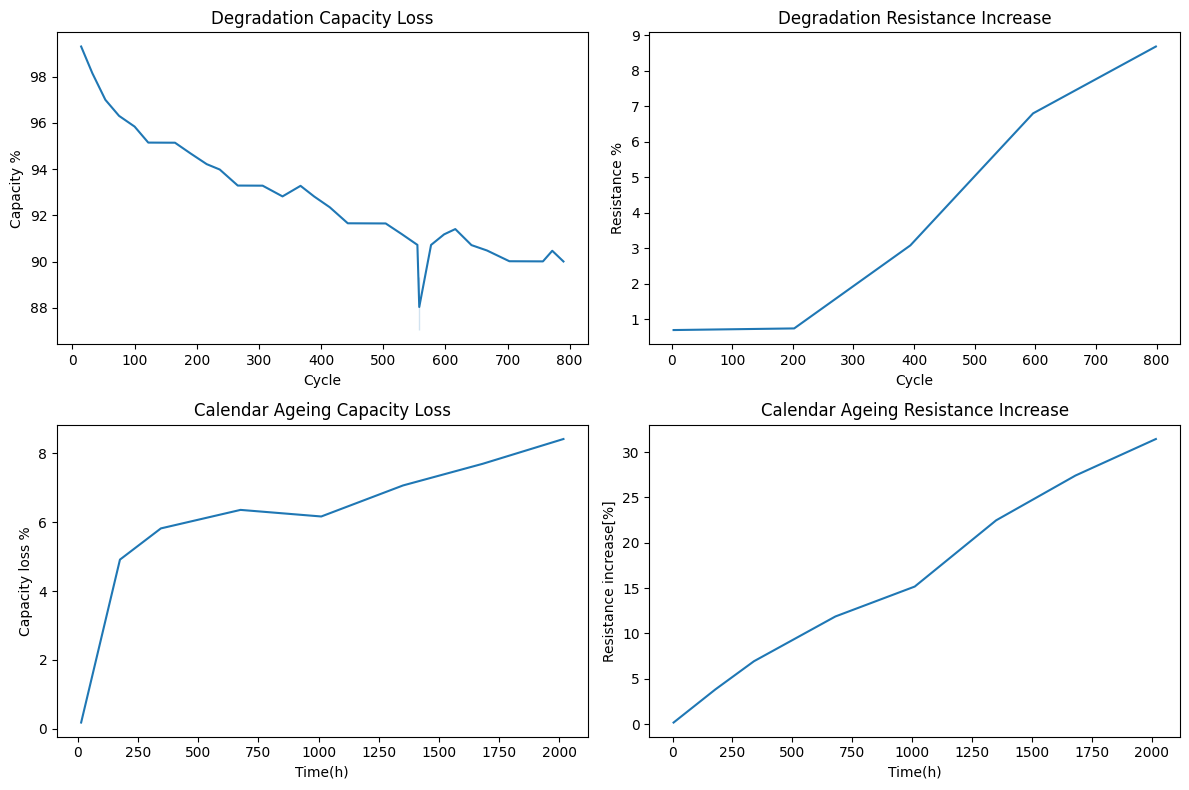

In [14]:
fig, axs = plt.subplots(2,2, figsize=(12,8))
sns.lineplot(data=deg_capacity, x='Cycle', y='Capacity %', ax=axs[0,0])
sns.lineplot(data=def_resistance, x='Cycle', y='Resistance %', ax=axs[0,1])
sns.lineplot(data=cal_resistance, x='Time(h)', y='Resistance increase[%]', ax=axs[1,1])
sns.lineplot(data=cal_capacity, x='Time(h)', y='Capacity loss %', ax=axs[1,0])

axs[0,0].set_title('Degradation Capacity Loss')
axs[0,1].set_title('Degradation Resistance Increase')
axs[1,0].set_title('Calendar Ageing Capacity Loss')
axs[1,1].set_title('Calendar Ageing Resistance Increase')
plt.tight_layout()
plt.show() 

In [15]:
NOM_CAPACITY = 2.496 #Ah
deg_capacity['Capacity loss'] = 100 - deg_capacity['Capacity %']
deg_capacity['Energy Throughput (Ah)'] = (deg_capacity['Cycle'] * NOM_CAPACITY * 2).cumsum()

$$ ln(s_{loss cycle}) = ln(a_c) - \frac{E_{ac}}{RT} + z_a ln(Ah) $$
regress $ ln(s_{loss cycle}) $ against $ ln{Ah} $

let $ K = ln(a_c) - \frac{E_{ac}}{RT} $

In [19]:
# linear regression in log space
ln_s = np.log(deg_capacity['Capacity loss'])
ln_Ah = np.log(deg_capacity['Energy Throughput (Ah)'])
# ln_Ah = np.array([ln_Ah, np.ones_like(ln_Ah)]).T
# beta = np.linalg.solve(ln_Ah.T @ ln_Ah, ln_Ah.T @ ln_s)

# K = beta[0]
# za = beta[1]
model = LinearRegression().fit(ln_Ah.values.reshape(-1,1), ln_s)
K = model.intercept_
za = model.coef_[0]
print(f"K: {K}, za: {za}")


K: -0.9750362366384266, za: 0.3063969455422179
